Problem Statement:
4) Data Analytics I
Create a Linear Regression Model using Python/R to predict home prices using Boston Housing
Dataset (https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains
information about various houses in Boston through different parameters. There are 506 samples and
14 feature variables in this dataset.
The objective is to predict the value of prices of the house using the given features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
boston=pd.read_csv(r"C:\Users\Lenovo\Desktop\Data Science Practicals\Data_Science\04_Data Analytics I\HousingData.csv")

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
boston.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [6]:
boston=boston.dropna(axis=0)

In [7]:
boston=boston.dropna(axis=1)

In [8]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.17783,0.0,9.69,0.0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10,17.5
500,0.22438,0.0,9.69,0.0,0.585,6.027,79.7,2.4982,6,391,19.2,396.90,14.33,16.8
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9


In [9]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB


In [10]:
boston.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000
mean,3.690136,11.460660,11.000863,0.068528,0.553215,6.280015,68.932741,3.805268,9.403553,406.431472,18.537563,358.490939,12.769112,22.359645
std,9.202423,23.954082,6.908364,0.252971,0.113112,0.697985,27.888705,2.098571,8.633451,168.312419,2.166460,89.283295,7.308430,9.142979
min,0.006320,0.000000,0.460000,0.000000,0.389000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,2.600000,1.730000,5.000000
25%,0.081955,0.000000,5.130000,0.000000,0.453000,5.879250,45.475000,2.110100,4.000000,280.250000,17.400000,376.707500,7.125000,16.800000
50%,0.268880,0.000000,8.560000,0.000000,0.538000,6.201500,77.700000,3.199200,5.000000,330.000000,19.100000,392.190000,11.300000,21.050000
75%,3.435973,12.500000,18.100000,0.000000,0.624000,6.605500,94.250000,5.116700,24.000000,666.000000,20.200000,396.900000,17.117500,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: >

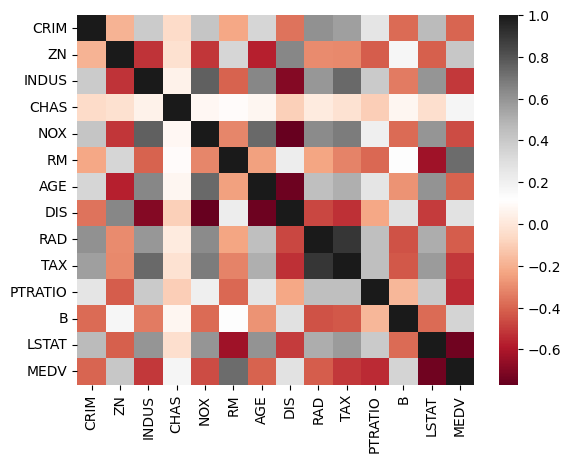

In [11]:
# Finding correlation matrix using Heatmap
sns.heatmap(boston.corr(), cmap = 'RdGy')

<Axes: >

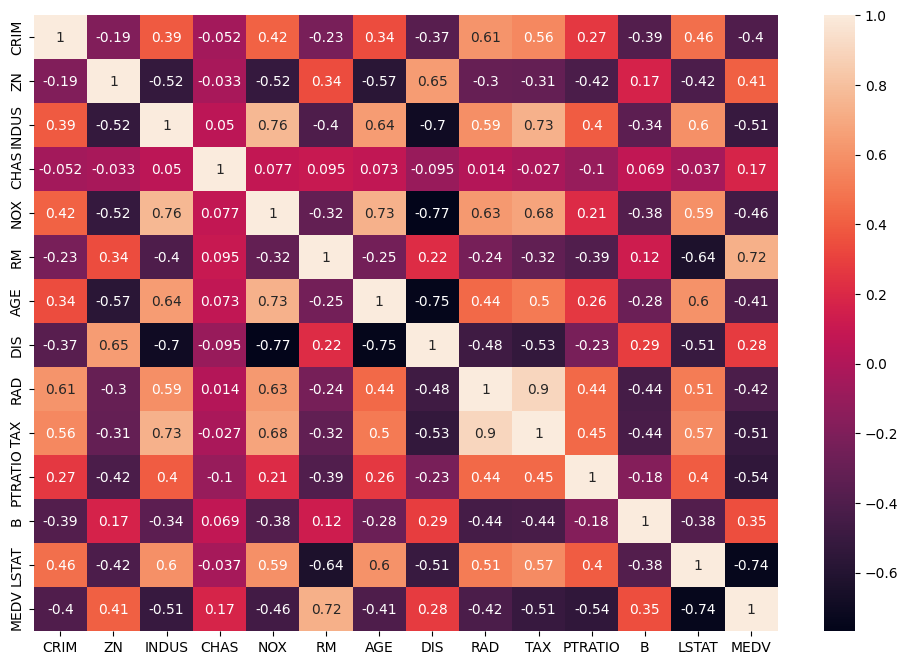

In [12]:
plt.subplots(figsize=(12,8))
sns.heatmap(boston.corr(), annot=True)

In [13]:
x=boston[["RM","LSTAT"]]

In [14]:
y=boston["MEDV"]

In [18]:
# splitting data to training and testing dataset.
#from sklearn.cross_validation import train_test_split
#the submodule cross_validation is renamed and deprecated to model_selection
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2,random_state=0)
print("xtrain shape : ", xtrain.shape)
print("xtest shape : ", xtest.shape)
print("ytrain shape : ", ytrain.shape)
print("ytest shape : ", ytest.shape)

xtrain shape :  (315, 2)
xtest shape :  (79, 2)
ytrain shape :  (315,)
ytest shape :  (79,)


In [19]:
#Build the model
#Applying Linear Regression Model to the dataset and predicting the prices. 
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [20]:
#fit the model
model.fit(xtrain, ytrain)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
LinearRegression()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# predicting the test set results
y_pred = model.predict(xtest)
y_pred

array([17.98184905, 25.71145065, 27.37604674, 37.38342649, 19.02415772,
       21.85811487, 28.25234014, 21.93857351, 27.21507874, 12.81181198,
       29.90263542, 12.29954503, 23.65278223, 28.85042056, 17.92338001,
       31.30792144, 23.25430606, 30.68788039, 23.43486911, 19.94303614,
       21.87730424, 30.56080825, 22.02239877, 19.47338385, 19.48564508,
       22.73998042, 17.21782251, 13.10128714, 20.28935763, 22.78586092,
        8.666648  , 18.90966425, 21.12557976, 25.27586216, 16.46304951,
       10.84492432, 26.64115594, 16.66758249, 21.91743544,  9.01988444,
       25.12176237, 11.86367929, 25.41936295, 22.39412388, 28.66852127,
       13.40185655, 21.79972486, 20.02569243, 13.54471458, 15.33086993,
       23.19040382, 22.70200735, 13.49107416, 32.54629126, 16.0600898 ,
       17.06427657, 17.5197973 , 23.37850815, 20.60885891, 26.4072699 ,
       19.704984  , 18.97064638, 26.35054277, 18.17507967, 19.67552162,
       35.95051945, 18.72918944, 27.95126627, 18.19620919, 31.00

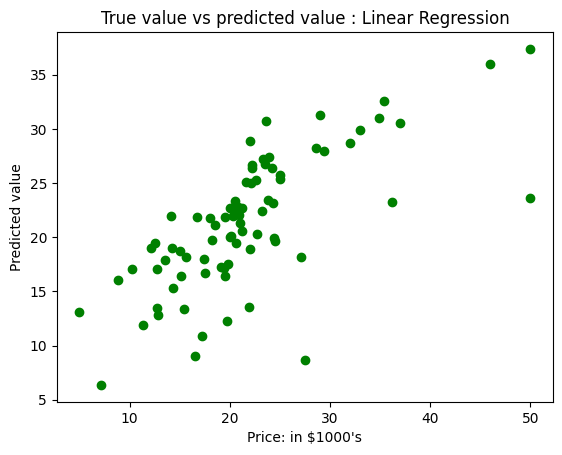

In [24]:
# Plotting Scatter graph to show the prediction
# results - 'ytrue' value vs 'y_pred' value
plt.scatter(ytest, y_pred, c = 'green')
plt.xlabel("Price: in $1000's")
plt.ylabel("Predicted value")
plt.title("True value vs predicted value : Linear Regression")
plt.show()

In [25]:
#Display accuracy of a model
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(ytest, y_pred)
mae = mean_absolute_error(ytest,y_pred)
model_score=model.score(xtest,ytest)
print("Mean Square Error : ", mse)
print("Mean Absolute Error : ", mae)
print("Model Score : ", model_score)

Mean Square Error :  33.71565830696706
Mean Absolute Error :  4.035196585193877
Model Score :  0.5099303003230867


In [26]:
# Test the model using user input
features=np.array([[6,19]])
prediction=model.predict(features)

In [27]:
#Calculate R2 score
from sklearn.metrics import r2_score
r2= r2_score(ytest,y_pred)
r2

0.5099303003230867

In [29]:
print(f"Predicted house Price for rm,lstat {features} user input is :",prediction)

Predicted house Price for rm,lstat [[ 6 19]] user input is : [17.20090915]
